<a href="https://colab.research.google.com/github/brunopless/TFM-Equipo-4-BDDS/blob/main/Modelo_XGBoost_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODELO XGBoost

El modelo escogido dentro del grupo de modelos de ML supervisados no lineales es el **XGBoost**. Se utilizaron las diferentes etiquetas de variables objetivo presentes en el dataset preparado que servirá para entrenar y probar los diferentes modelos.

Las diferentes etapas del proceso utilizado son las siguientes

##1. Carga de las librerías necesarias

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import seaborn as sns
from pandas.errors import ParserError
from scipy import stats
import matplotlib.pyplot as plt
from math import exp

## 2. Carga del dataset

El dataset utilizado en formato CSV se encuentra en un repositorio de GITHUB sobre el cual se tiene la URL.  Se carga un dataframe

In [ ]:
# URL en GITHUB del dataset a utilizar
url = 'https://raw.githubusercontent.com/brunopless/TFM-Equipo-4-BDDS/main/entrega-3/df_bcn_imputado.csv'

# Cargar el dataset en un DataFrame
# Probar el delimitador
try:
    df = pd.read_csv(url)  # Intentar con el delimitador por defecto (',')
except ParserError:
    df = pd.read_csv(url, sep=';')


Se visualizan las primeras líneas del dataset cargado

In [ ]:
df.head()

,Unnamed: 0,floor,price,operation,size,exterior,rooms,bathrooms,latitude,longitude,...,numero_buenasmigas_cercanos_mas_de_cero,numero_clubesnocturnos_cercanos_mas_de_cero,numero_mcdonalds_cercanos_mas_de_cero,numero_metro_cercanos_mas_de_cero,numero_parking_cercanos_mas_de_cero,numero_parkingbici_cercanos_mas_de_cero,numero_parques_cercanos_mas_de_cero,numero_playas_cercanos_mas_de_cero,numero_santagloria_cercanos_mas_de_cero,numero_vivari_cercanos_mas_de_cero
0,1,4.0,749.0,rent,45.0,1,1,1,41.383719,2.175998,...,1,0,0,0,0,0,0,0,0,0
1,2,2.0,4400.0,rent,170.0,1,3,4,41.397182,2.142885,...,0,0,0,0,0,0,0,0,0,0
2,3,5.0,1700.0,rent,74.0,1,2,1,41.405040,2.211389,...,0,0,0,0,0,0,0,0,0,0
3,4,1.0,2369.0,rent,127.0,1,2,2,41.408746,2.215716,...,0,0,0,0,0,0,1,1,0,0
4,5,0.0,4000.0,rent,55.0,1,1,1,41.392297,2.169440,...,0,1,0,0,0,0,0,0,1,1


Clusterizamos la base anterior

In [ ]:
from sklearn.cluster import KMeans

lat_col = 'latitude'
lon_col = 'longitude'

# Aplicar KMeans para 25 clusters
n_clusters = 25
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Ajustar el modelo solo con las columnas de latitud y longitud
df['cluster'] = kmeans.fit_predict(df[[lat_col, lon_col]])



Se visualizan los campos cargados en el dataframe

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17690 entries, 0 to 17689
Data columns (total 54 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   17690 non-null  int64  
 1   floor                                        17690 non-null  float64
 2   price                                        17690 non-null  float64
 3   operation                                    17690 non-null  object 
 4   size                                         17690 non-null  float64
 5   exterior                                     17690 non-null  int64  
 6   rooms                                        17690 non-null  int64  
 7   bathrooms                                    17690 non-null  int64  
 8   latitude                                     17690 non-null  float64
 9   longitude                                    17690 non-null  float64
 10

Se hace **One Hot Encoding** sobre la variable **cluster**

In [ ]:


df = pd.get_dummies(df, columns=['cluster'], prefix=['cluster'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17690 entries, 0 to 17689
Data columns (total 78 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   17690 non-null  int64  
 1   floor                                        17690 non-null  float64
 2   price                                        17690 non-null  float64
 3   operation                                    17690 non-null  object 
 4   size                                         17690 non-null  float64
 5   exterior                                     17690 non-null  int64  
 6   rooms                                        17690 non-null  int64  
 7   bathrooms                                    17690 non-null  int64  
 8   latitude                                     17690 non-null  float64
 9   longitude                                    17690 non-null  float64
 10

Se visualiza la columa **0 Unnamed: 0** (la cual debe ser eliminada para poder modelar y tambien se ven las etiquetas de las siguientes variables objetivos, las cuales van a ser objeto de diferentes modelos y determinar el de mejor resultado con las variables de entrada:

1.   price
2.   log_price
3.   price_m2
4.   log_price_m2

Se procede con la eliminación de la columna 0 (**Unnamed:0**) y se guarda en el dataframe final **dfred** para que sea esta último en los modelos a realizar



In [ ]:
# Se elimina la columna 0. de acuerdo con la ubicación visualizada
dfred= df.drop(df.columns[[0]], axis=1)

#se comprueba el dataframe final
dfred.head()

,floor,price,operation,size,exterior,rooms,bathrooms,latitude,longitude,newDevelopment,...,cluster_15,cluster_16,cluster_17,cluster_18,cluster_19,cluster_20,cluster_21,cluster_22,cluster_23,cluster_24
0,4.0,749.0,rent,45.0,1,1,1,41.383719,2.175998,0,...,False,False,False,False,False,True,False,False,False,False
1,2.0,4400.0,rent,170.0,1,3,4,41.397182,2.142885,0,...,False,False,False,False,True,False,False,False,False,False
2,5.0,1700.0,rent,74.0,1,2,1,41.405040,2.211389,0,...,False,False,False,False,False,False,False,False,False,False
3,1.0,2369.0,rent,127.0,1,2,2,41.408746,2.215716,0,...,False,False,False,False,False,False,False,False,False,False
4,0.0,4000.0,rent,55.0,1,1,1,41.392297,2.169440,0,...,False,False,False,False,False,False,False,False,False,False


Volver numericas las variables booleanas

In [ ]:

# Iterar sobre las columnas que comienzan con 'cluster_'
for column in dfred.columns:
  if column.startswith('cluster_'):
    # Reemplazar True con 1 y False con 0
    dfred[column] = dfred[column].astype(int)

# Se visualiza el dataframe resultante
dfred.head()


,floor,price,operation,size,exterior,rooms,bathrooms,latitude,longitude,newDevelopment,...,cluster_15,cluster_16,cluster_17,cluster_18,cluster_19,cluster_20,cluster_21,cluster_22,cluster_23,cluster_24
0,4.0,749.0,rent,45.0,1,1,1,41.383719,2.175998,0,...,0,0,0,0,0,1,0,0,0,0
1,2.0,4400.0,rent,170.0,1,3,4,41.397182,2.142885,0,...,0,0,0,0,1,0,0,0,0,0
2,5.0,1700.0,rent,74.0,1,2,1,41.405040,2.211389,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,2369.0,rent,127.0,1,2,2,41.408746,2.215716,0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,4000.0,rent,55.0,1,1,1,41.392297,2.169440,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Modelo con target PRICE

R² en el conjunto de entrenamiento: 0.8421511799168406
R² en el conjunto de prueba: 0.6995015138221485
R² ajustado en el conjunto de entrenamiento: 0.8412537288604873
R² ajustado  en el conjunto de prueba: 0.6954841543812682
MAE en el conjunto de entrenamiento: 406.1056710086093
MAE en el conjunto de prueba: 552.4358248074109
MAPE en el conjunto de entrenamiento: 18.26572401616201
MAPE en el conjunto de prueba: 23.941658896002913


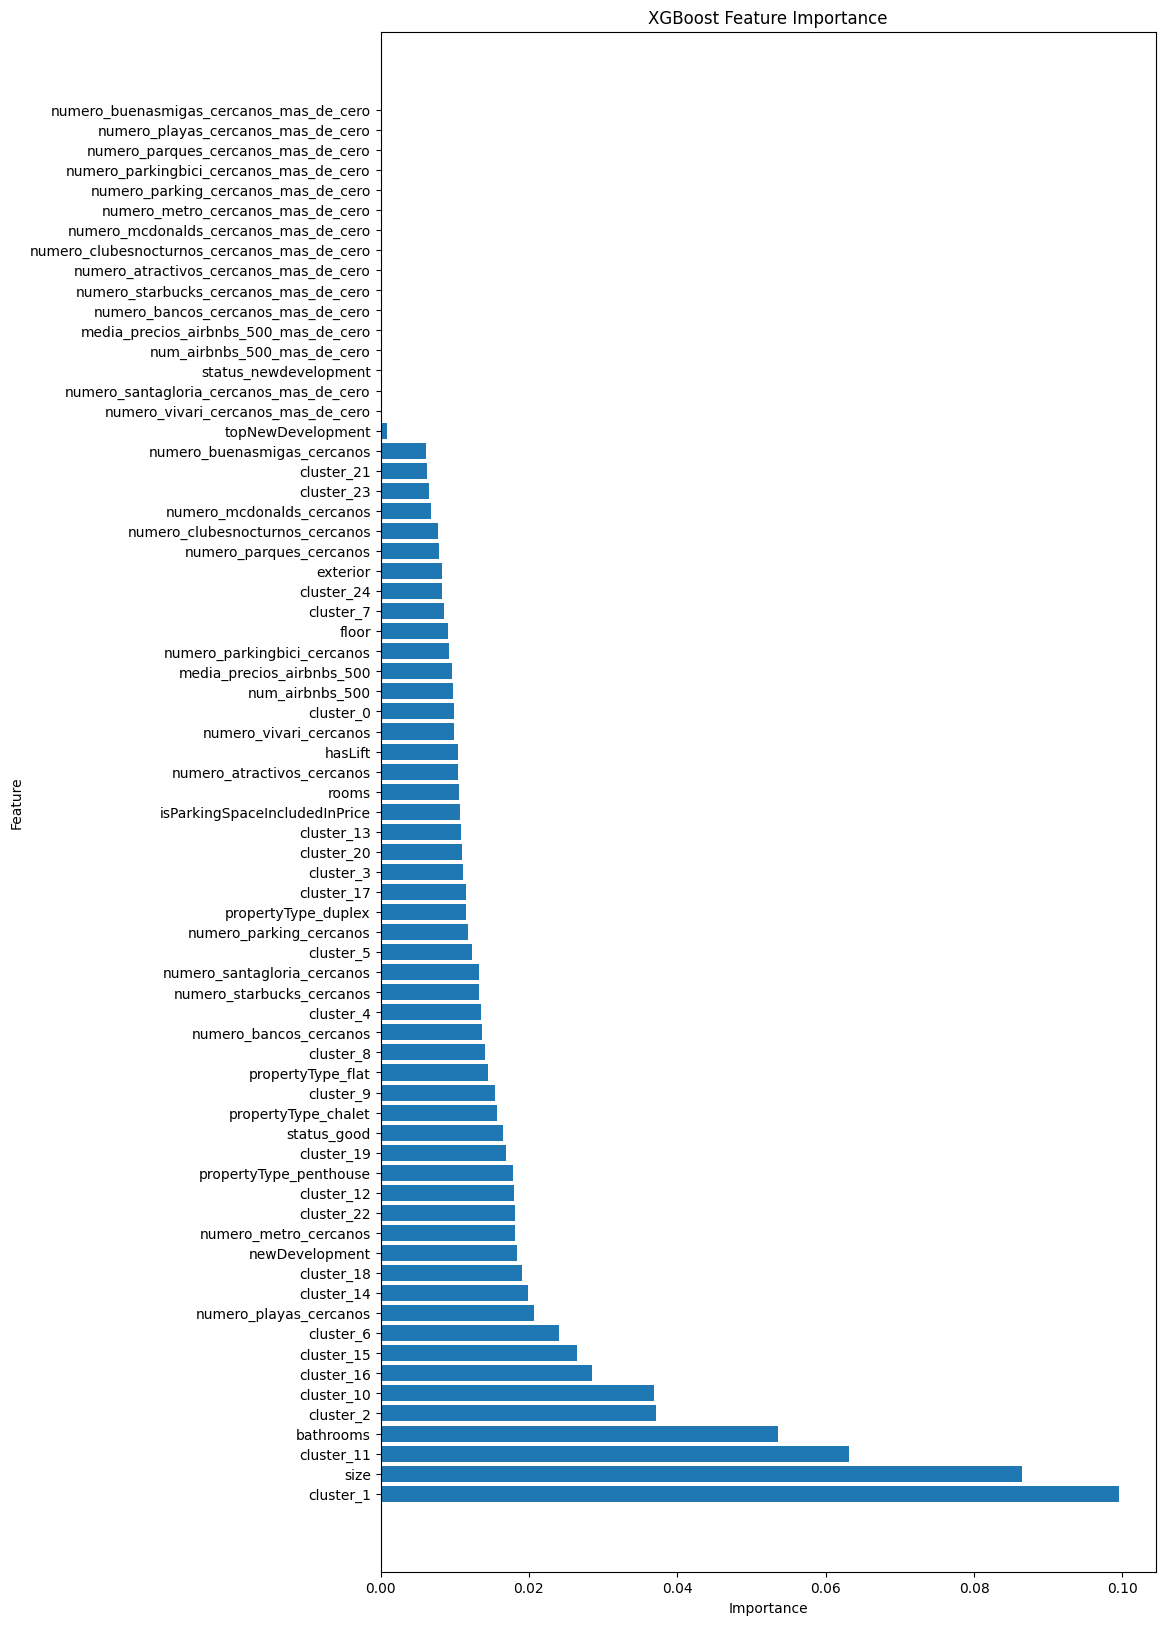

In [ ]:
# lista de las columnas a eliminar para correr el modelo
columns_to_drop = ['operation', 'price', 'log_price',
                   'price_m2', 'log_price_m2', 'latitude', 'longitude']

# Se define el conjunto de variables X y la variable objetivo Y (price)

X = dfred.drop(columns_to_drop , axis=1)
y = dfred['price']

# Se hace el One Hot encoding para las variables categóricas
X = pd.get_dummies(X)


# División data de entrenamiento 70% y prueba 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Se crea el modelo
model = xgb.XGBRegressor(objective='reg:squarederror')

# Se entrena el modelo
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de entrenamiento
y_train_pred = model.predict(X_train)

# Hacer predicciones en el conjunto de prueba
y_test_pred = model.predict(X_test)

# Calcular R² para el conjunto de entrenamiento
r2_train = r2_score(y_train, y_train_pred)
print(f'R² en el conjunto de entrenamiento: {r2_train}')

# Calcular R² para el conjunto de prueba
r2_test = r2_score(y_test, y_test_pred)
print(f'R² en el conjunto de prueba: {r2_test}')

# Calcular R^2 Ajustado conjunto entrenamiento
n = len(y_train)  # Número de observaciones en el conjunto de prueba
k = X_train.shape[1]  # Número de variables predictivas
r2_ajustado_train = 1 - (1 - r2_train) * (n - 1) / (n - k - 1)
print(f'R² ajustado en el conjunto de entrenamiento: {r2_ajustado_train}')

# Calcular R^2 Ajustado conjunto prueba
n = len(y_test)  # Número de observaciones en el conjunto de prueba
k = X_test.shape[1]  # Número de variables predictivas
r2_ajustado_test = 1 - (1 - r2_test) * (n - 1) / (n - k - 1)
print(f'R² ajustado  en el conjunto de prueba: {r2_ajustado_test}')

# Calcular MAE conjunto entrenamiento
mae_train = mean_absolute_error(y_train, y_train_pred)
print(f'MAE en el conjunto de entrenamiento: {mae_train}')

# Calcular MAE conjunto prueba
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f'MAE en el conjunto de prueba: {mae_test}')

# Calcular MAPE conjunto entrenamiento
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
print(f'MAPE en el conjunto de entrenamiento: {mape_train}')

# Calcular MAPE conjunto prueba
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
print(f'MAPE en el conjunto de prueba: {mape_test}')

# Se identifica la importancia de las variables de entrada
feature_importances = model.feature_importances_

# Se prepara la grafica de importancia de variables de entrada
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Grafica la importancia de las variables de entrada
plt.figure(figsize=(10, 20))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()

Se evaluan los residuos del modelo corridos para comprobar la distribución de los mismos

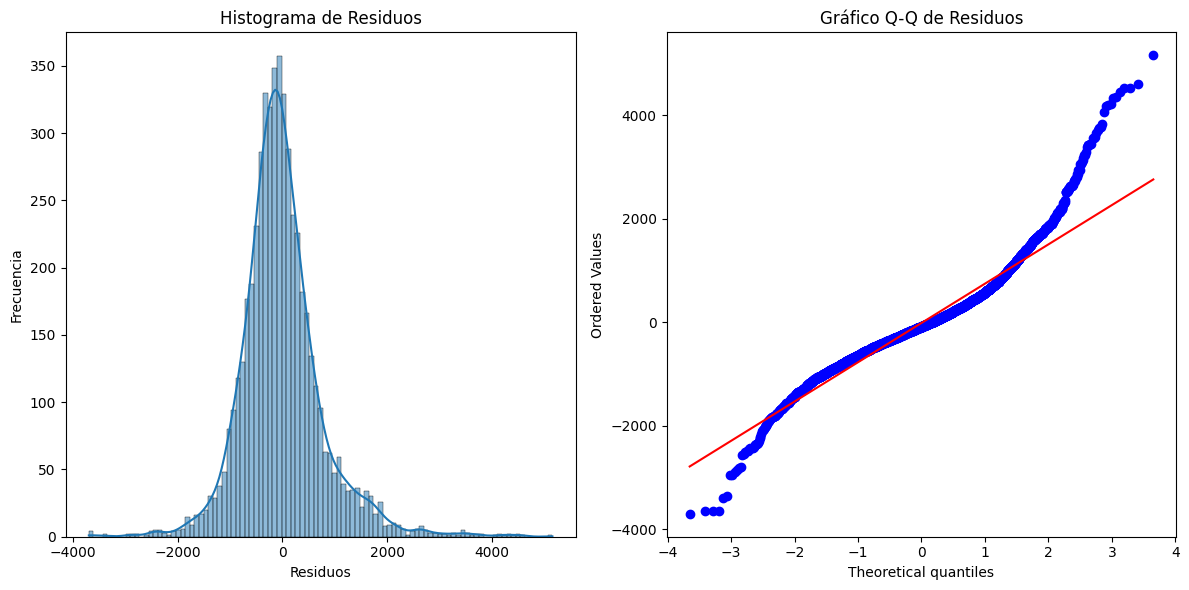

In [ ]:
# Calcular los residuos
residuals = y_test - y_test_pred

# Visualizar los residuos
plt.figure(figsize=(12, 6))

# Histograma de residuos
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

# Gráfico Q-Q
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')

plt.tight_layout()
plt.show()

Se corren las pruebas de normalidad de los residuos

In [ ]:
# Prueba de Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test: Estadístico={shapiro_test.statistic}, p-valor={shapiro_test.pvalue}')

# Prueba de Kolmogorov-Smirnov
ks_test = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
print(f'Kolmogorov-Smirnov Test: Estadístico={ks_test.statistic}, p-valor={ks_test.pvalue}')

Shapiro-Wilk Test: Estadístico=0.9322121042417841, p-valor=6.994941537044941e-44
Kolmogorov-Smirnov Test: Estadístico=0.08756918040665651, p-valor=7.387994943805295e-36


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5307.
  res = hypotest_fun_out(*samples, **kwds)


## 4. Modelo con target log_price

R² en el conjunto de entrenamiento: 0.8112004387073062
R² en el conjunto de entrenamiento trasnformado log: 0.8286711835975911
R² en el conjunto de prueba: 0.6757496306587345
R² en el conjunto de prueba trasnformado log: 0.6899062167912139
R² ajustado en el conjunto de entrenamiento: 0.8276970918864013
R² ajustado  en el conjunto de prueba: 0.6857605779782622
MAE en el conjunto de entrenamiento: 0.16023881782782698
MAE en el conjunto de prueba: 0.2153292566295915
MAPE en el conjunto de entrenamiento: 2.08444200844731
MAPE en el conjunto de prueba: 2.7978524801500737
MAPE transformado log en el conjunto de entrenamiento: 16.238118215702123
MAPE transformado log en el conjunto de prueba: 22.227892418214157


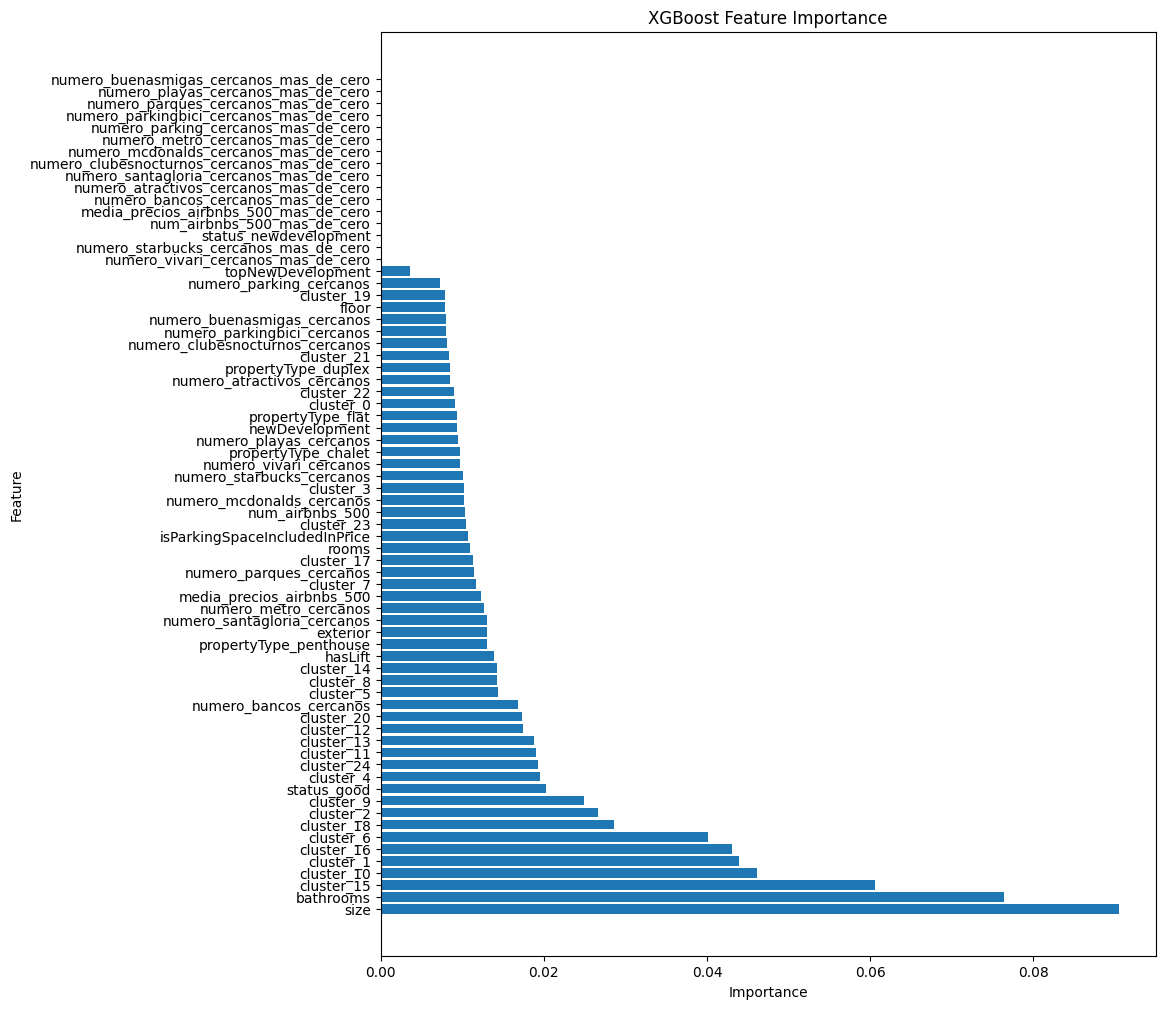

In [ ]:


# Se define el conjunto de variables X y la variable objetivo Y (log_price)
X1 = dfred.drop(columns_to_drop , axis=1)
y1 = dfred['log_price']

# Se hace el One Hot encoding para las variables categóricas
X1 = pd.get_dummies(X1)

# División data de entrenamiento 70% y prueba 30%
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)

# Se crea el modelo
model1 = xgb.XGBRegressor(objective='reg:squarederror')

# Se entrena el modelo
model1.fit(X_train1, y_train1)

# Hacer predicciones en el conjunto de entrenamiento
y_train_pred1 = model1.predict(X_train1)

# Hacer predicciones en el conjunto de prueba
y_test_pred1 = model1.predict(X_test1)

# Calcular R² para el conjunto de entrenamiento
r2_train1 = r2_score(y_train1, y_train_pred1)
print(f'R² en el conjunto de entrenamiento: {r2_train1}')

# Calcular R² para el conjunto de entrenamiento transformado log
r2_trainl1 = r2_score(np.exp(y_train1), np.exp(y_train_pred1))
print(f'R² en el conjunto de entrenamiento trasnformado log: {r2_trainl1}')

# Calcular R² para el conjunto de prueba
r2_test1 = r2_score(y_test1, y_test_pred1)
print(f'R² en el conjunto de prueba: {r2_test1}')

# Calcular R² para el conjunto de prueba transformado log
r2_testl1 = r2_score(np.exp(y_test1), np.exp(y_test_pred1))
print(f'R² en el conjunto de prueba trasnformado log: {r2_testl1}')

# Calcular R^2 Ajustado conjunto entrenamiento
n = len(y_train1)  # Número de observaciones en el conjunto de prueba
k = X_train1.shape[1]  # Número de variables predictivas
r2_ajustado_train1 = 1 - (1 - r2_trainl1) * (n - 1) / (n - k - 1)
print(f'R² ajustado en el conjunto de entrenamiento: {r2_ajustado_train1}')

# Calcular R^2 Ajustado conjunto prueba
n = len(y_test1)  # Número de observaciones en el conjunto de prueba
k = X_test1.shape[1]  # Número de variables predictivas
r2_ajustado_test1 = 1 - (1 - r2_testl1) * (n - 1) / (n - k - 1)
print(f'R² ajustado  en el conjunto de prueba: {r2_ajustado_test1}')

# Calcular MAE conjunto entrenamiento
mae_train1 = mean_absolute_error(y_train1, y_train_pred1)
print(f'MAE en el conjunto de entrenamiento: {mae_train1}')

# Calcular MAE conjunto prueba
mae_test1 = mean_absolute_error(y_test1, y_test_pred1)
print(f'MAE en el conjunto de prueba: {mae_test1}')

# Calcular MAPE conjunto entrenamiento
mape_train1 = np.mean(np.abs((y_train1 - y_train_pred1) / y_train1)) * 100
print(f'MAPE en el conjunto de entrenamiento: {mape_train1}')

# Calcular MAPE conjunto prueba
mape_test1 = np.mean(np.abs((y_test1 - y_test_pred1) / y_test1)) * 100
print(f'MAPE en el conjunto de prueba: {mape_test1}')

# Calcular MAPE conjunto entrenamiento transformado log
mape_trainl1 = np.mean(np.abs((np.exp(y_train1) - np.exp(y_train_pred1)) / np.exp(y_train1))) * 100
print(f'MAPE transformado log en el conjunto de entrenamiento: {mape_trainl1}')

# Calcular MAPE conjunto prueba transformado log
mape_testl1 = np.mean(np.abs((np.exp(y_test1) - np.exp(y_test_pred1)) / np.exp(y_test1))) * 100
print(f'MAPE transformado log en el conjunto de prueba: {mape_testl1}')

# Se identifica la importancia de las variables de entrada
feature_importances1 = model1.feature_importances_

# Se prepara la grafica de importancia de variables de entrada
feature_importance_df = pd.DataFrame({'Feature': X1.columns, 'Importance': feature_importances1})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Grafica la importancia de las variables de entrada
plt.figure(figsize=(10, 12))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()

Se evaluan los residuos del modelo corridos para comprobar la distribución de los mismos

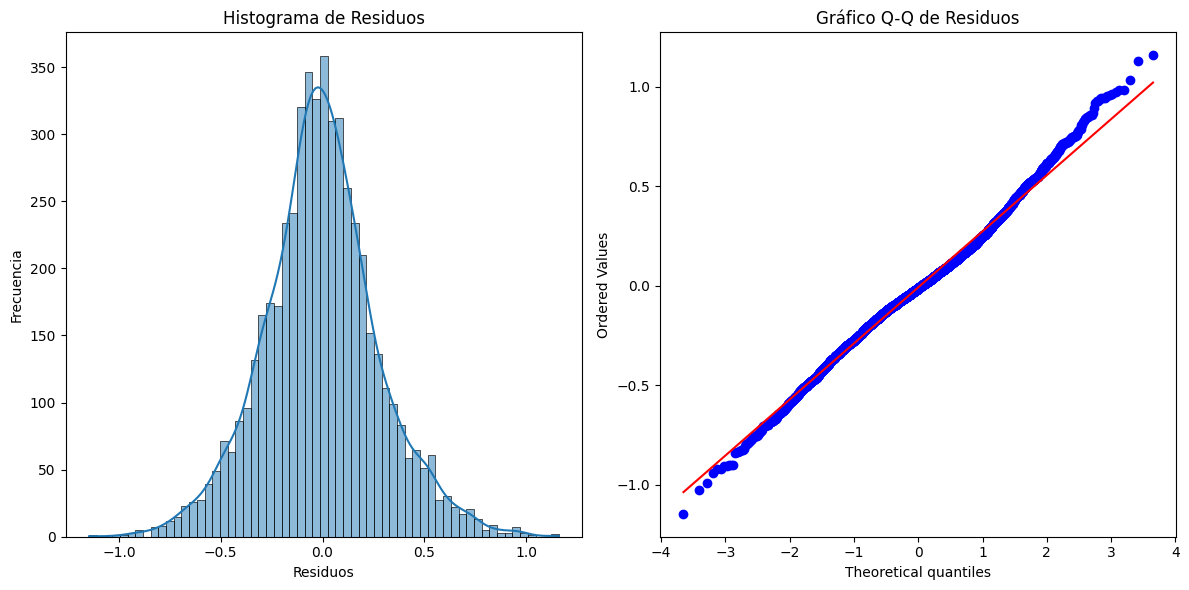

In [ ]:
# Calcular los residuos
residuals1 = y_test1 - y_test_pred1

# Visualizar los residuos
plt.figure(figsize=(12, 6))

# Histograma de residuos
plt.subplot(1, 2, 1)
sns.histplot(residuals1, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

# Gráfico Q-Q
plt.subplot(1, 2, 2)
stats.probplot(residuals1, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')

plt.tight_layout()
plt.show()

## 5. Modelo con target log_price_m2

R² en el conjunto de entrenamiento: 0.8112004387073062
R² en el conjunto de entrenamiento trasnformado log: 0.7249546744096014
R² en el conjunto de prueba: 0.5254259234507119
R² en el conjunto de prueba trasnformado log: 0.5226379399726528
R² ajustado en el conjunto de entrenamiento: 0.7233909014408451
R² ajustado  en el conjunto de prueba: 0.5162560942503621
MAE en el conjunto de entrenamiento: 0.14944646145534976
MAE en el conjunto de prueba: 0.19778054570645437
MAPE en el conjunto de entrenamiento: 4.564372786324226
MAPE en el conjunto de prueba: 6.060829963386289
MAPE transformado log en el conjunto de entrenamiento: 15.169801039204625
MAPE transformado log en el conjunto de prueba: 20.342555327825593


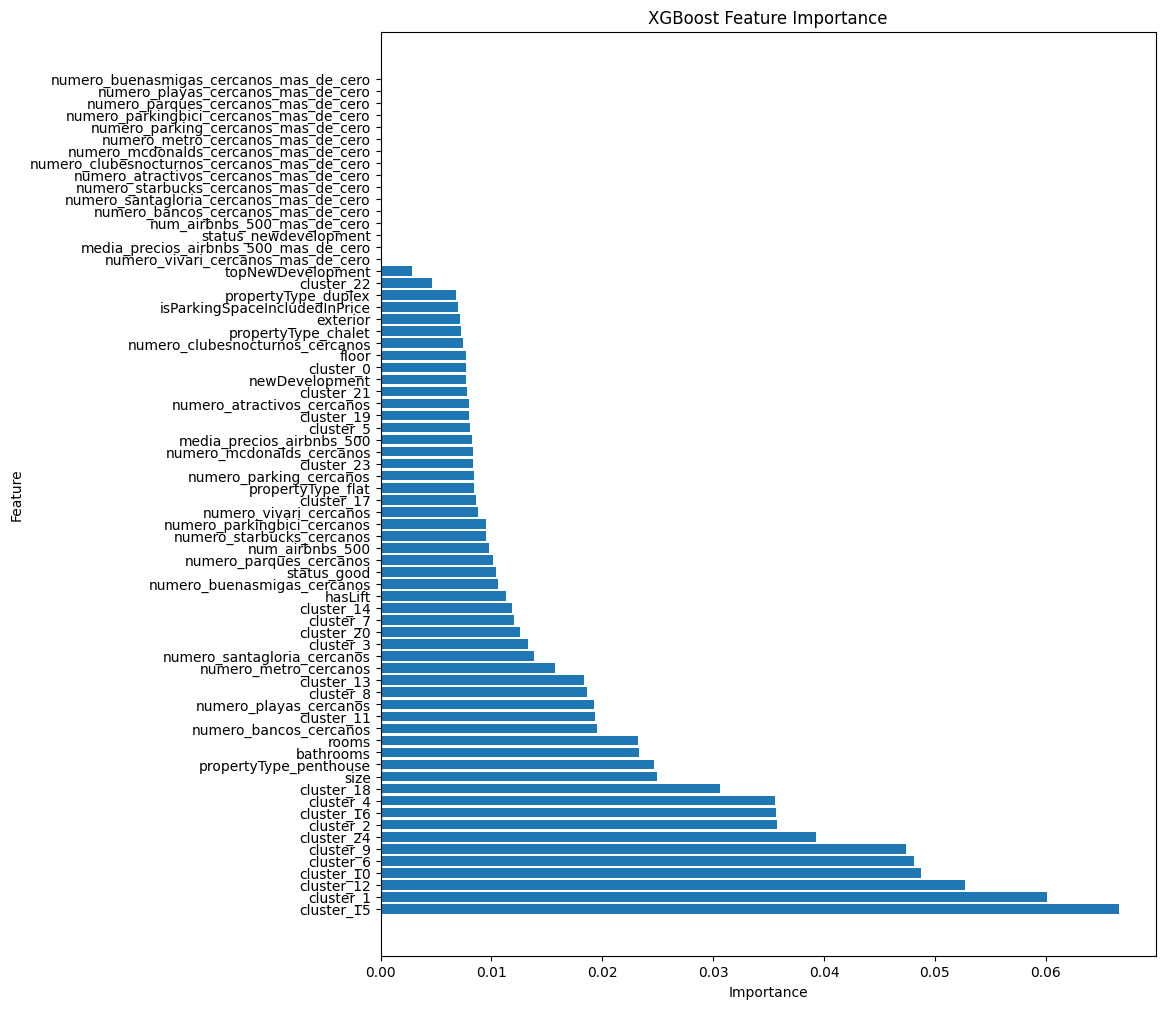

In [ ]:


# Se define el conjunto de variables X y la variable objetivo Y (log_price_m2)
X2 = dfred.drop(columns_to_drop , axis=1)
y2 = dfred['log_price_m2']

# Se hace el One Hot encoding para las variables categóricas
X2 = pd.get_dummies(X2)

# División data de entrenamiento 70% y prueba 30%
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42)

# Se crea el modelo
model2 = xgb.XGBRegressor(objective='reg:squarederror')

# Se entrena el modelo
model2.fit(X_train2, y_train2)

# Hacer predicciones en el conjunto de entrenamiento
y_train_pred2 = model2.predict(X_train2)

# Hacer predicciones en el conjunto de prueba
y_test_pred2 = model2.predict(X_test2)

# Calcular R² para el conjunto de entrenamiento
r2_train2 = r2_score(y_train1, y_train_pred1)
print(f'R² en el conjunto de entrenamiento: {r2_train2}')

# Calcular R² para el conjunto de entrenamiento transformado log
r2_trainl2 = r2_score(np.exp(y_train2), np.exp(y_train_pred2))
print(f'R² en el conjunto de entrenamiento trasnformado log: {r2_trainl2}')

# Calcular R² para el conjunto de prueba
r2_test2 = r2_score(y_test2, y_test_pred2)
print(f'R² en el conjunto de prueba: {r2_test2}')

# Calcular R² para el conjunto de prueba transformado log
r2_testl2 = r2_score(np.exp(y_test2), np.exp(y_test_pred2))
print(f'R² en el conjunto de prueba trasnformado log: {r2_testl2}')

# Calcular R^2 Ajustado conjunto entrenamiento
n = len(y_train2)
k = X_train2.shape[1]
r2_ajustado_train2 = 1 - (1 - r2_trainl2) * (n - 1) / (n - k - 1)
print(f'R² ajustado en el conjunto de entrenamiento: {r2_ajustado_train2}')

# Calcular R^2 Ajustado conjunto prueba
n = len(y_test2)
k = X_test2.shape[1]
r2_ajustado_test2 = 1 - (1 - r2_testl2) * (n - 1) / (n - k - 1)
print(f'R² ajustado  en el conjunto de prueba: {r2_ajustado_test2}')

# Calcular MAE conjunto entrenamiento
mae_train2 = mean_absolute_error(y_train2, y_train_pred2)
print(f'MAE en el conjunto de entrenamiento: {mae_train2}')

# Calcular MAE conjunto prueba
mae_test2 = mean_absolute_error(y_test2, y_test_pred2)
print(f'MAE en el conjunto de prueba: {mae_test2}')

# Calcular MAPE conjunto entrenamiento
mape_train2 = np.mean(np.abs((y_train2 - y_train_pred2) / y_train2)) * 100
print(f'MAPE en el conjunto de entrenamiento: {mape_train2}')

# Calcular MAPE conjunto prueba
mape_test2 = np.mean(np.abs((y_test2 - y_test_pred2) / y_test2)) * 100
print(f'MAPE en el conjunto de prueba: {mape_test2}')

# Calcular MAPE conjunto entrenamiento transformado log
mape_trainl2 = np.mean(np.abs((np.exp(y_train2) - np.exp(y_train_pred2)) / np.exp(y_train2))) * 100
print(f'MAPE transformado log en el conjunto de entrenamiento: {mape_trainl2}')

# Calcular MAPE conjunto prueba transformado log
mape_testl2 = np.mean(np.abs((np.exp(y_test2) - np.exp(y_test_pred2)) / np.exp(y_test2))) * 100
print(f'MAPE transformado log en el conjunto de prueba: {mape_testl2}')

# Se identifica la importancia de las variables de entrada
feature_importances2 = model2.feature_importances_

# Se prepara la grafica de importancia de variables de entrada
feature_importance_df = pd.DataFrame({'Feature': X2.columns, 'Importance': feature_importances2})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Grafica la importancia de las variables de entrada
plt.figure(figsize=(10, 12))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()

Se evaluan los residuos del modelo corridos para comprobar la distribución de los mismos

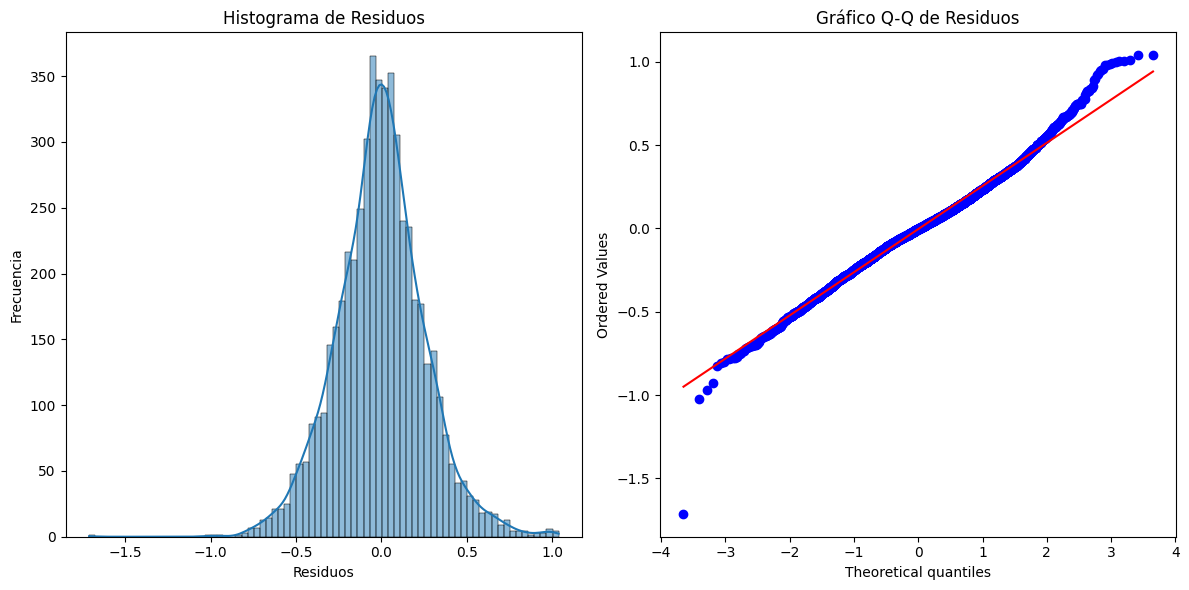

In [ ]:
# Calcular los residuos
residuals2 = y_test2 - y_test_pred2

# Visualizar los residuos
plt.figure(figsize=(12, 6))

# Histograma de residuos
plt.subplot(1, 2, 1)
sns.histplot(residuals2, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

# Gráfico Q-Q
plt.subplot(1, 2, 2)
stats.probplot(residuals2, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')

plt.tight_layout()
plt.show()

## 6. Modelo con target price_m2

R² en el conjunto de entrenamiento: 0.7533859193991339
R² en el conjunto de prueba: 0.5167946250140488
R² ajustado en el conjunto de entrenamiento: 0.7519837925601102
R² ajustado  en el conjunto de prueba: 0.5103346601078196
MAE en el conjunto de entrenamiento: 4.493792046280536
MAE en el conjunto de prueba: 6.08899105809409
MAPE en el conjunto de entrenamiento: 16.55913100538
MAPE en el conjunto de prueba: 22.130400297399845


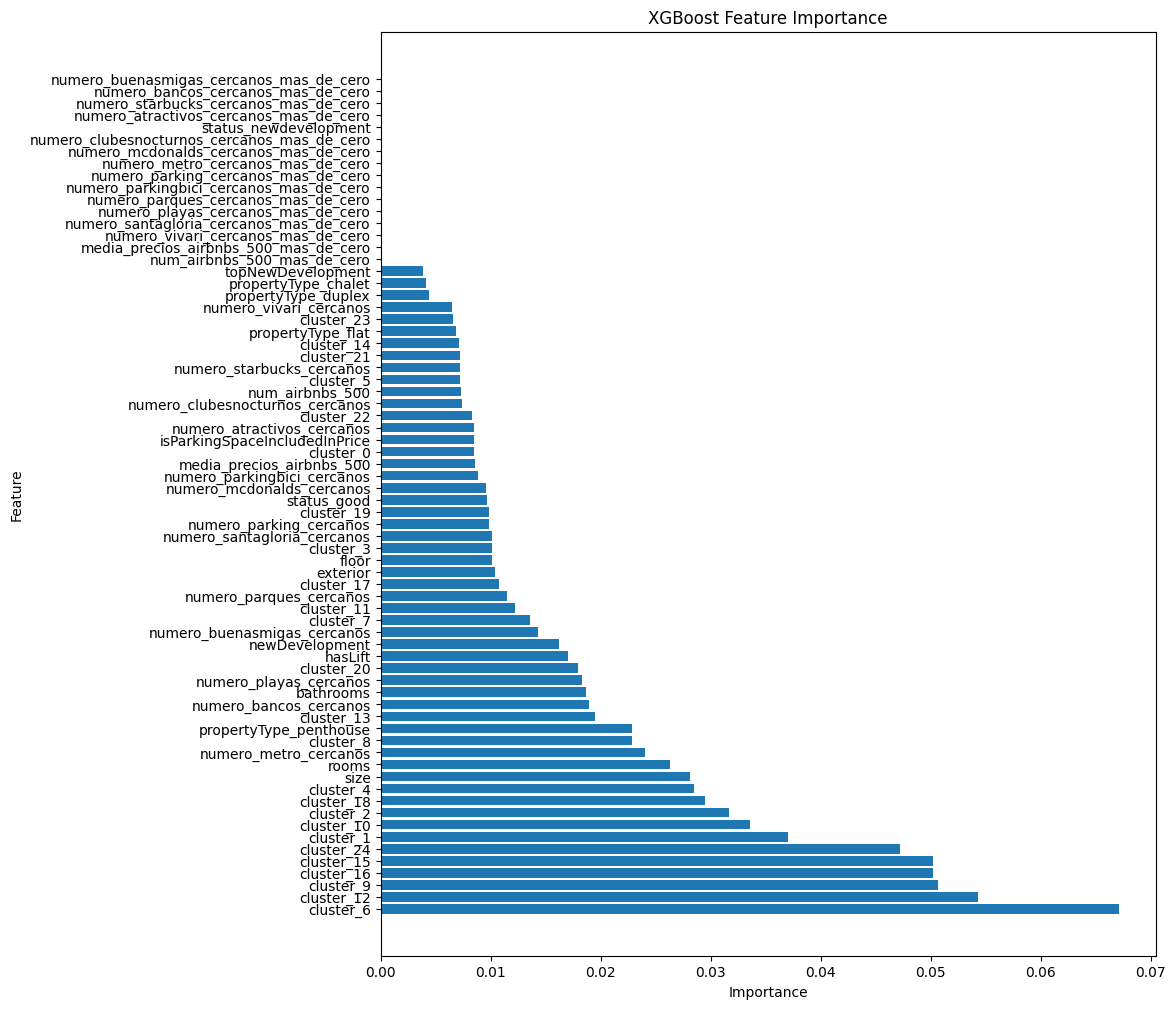

In [ ]:


# Se define el conjunto de variables X y la variable objetivo Y (price_m2)
X3 = dfred.drop(columns_to_drop , axis=1)
y3 = dfred['price_m2']

# Se hace el One Hot encoding para las variables categóricas
X3 = pd.get_dummies(X3)

# División data de entrenamiento 70% y prueba 30%
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.3, random_state=42)

# Se crea el modelo
model3 = xgb.XGBRegressor(objective='reg:squarederror')

# Se entrena el modelo
model3.fit(X_train3, y_train3)

# Hacer predicciones en el conjunto de entrenamiento
y_train_pred3 = model3.predict(X_train3)

# Hacer predicciones en el conjunto de prueba
y_test_pred3 = model3.predict(X_test3)

# Calcular R² para el conjunto de entrenamiento
r2_train3 = r2_score(y_train3, y_train_pred3)
print(f'R² en el conjunto de entrenamiento: {r2_train3}')

# Calcular R² para el conjunto de prueba
r2_test3 = r2_score(y_test3, y_test_pred3)
print(f'R² en el conjunto de prueba: {r2_test3}')

# Calcular R^2 Ajustado conjunto entrenamiento
n = len(y_train3)  # Número de observaciones en el conjunto de prueba
k = X_train3.shape[1]  # Número de variables predictivas
r2_ajustado_train3 = 1 - (1 - r2_train3) * (n - 1) / (n - k - 1)
print(f'R² ajustado en el conjunto de entrenamiento: {r2_ajustado_train3}')

# Calcular R^2 Ajustado conjunto prueba
n = len(y_test3)  # Número de observaciones en el conjunto de prueba
k = X_test3.shape[1]  # Número de variables predictivas
r2_ajustado_test3 = 1 - (1 - r2_test3) * (n - 1) / (n - k - 1)
print(f'R² ajustado  en el conjunto de prueba: {r2_ajustado_test3}')

# Calcular MAE conjunto entrenamiento
mae_train3 = mean_absolute_error(y_train3, y_train_pred3)
print(f'MAE en el conjunto de entrenamiento: {mae_train3}')

# Calcular MAE conjunto prueba
mae_test3 = mean_absolute_error(y_test3, y_test_pred3)
print(f'MAE en el conjunto de prueba: {mae_test3}')

# Calcular MAPE conjunto entrenamiento
mape_train3 = np.mean(np.abs((y_train3 - y_train_pred3) / y_train3)) * 100
print(f'MAPE en el conjunto de entrenamiento: {mape_train3}')

# Calcular MAPE conjunto prueba
mape_test3 = np.mean(np.abs((y_test3 - y_test_pred3) / y_test3)) * 100
print(f'MAPE en el conjunto de prueba: {mape_test3}')

# Get feature importances
feature_importances3 = model3.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': X3.columns, 'Importance': feature_importances3})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 12))  # Increase the height of the plot
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()

Se evaluan los residuos del modelo corridos para comprobar la distribución de los mismos

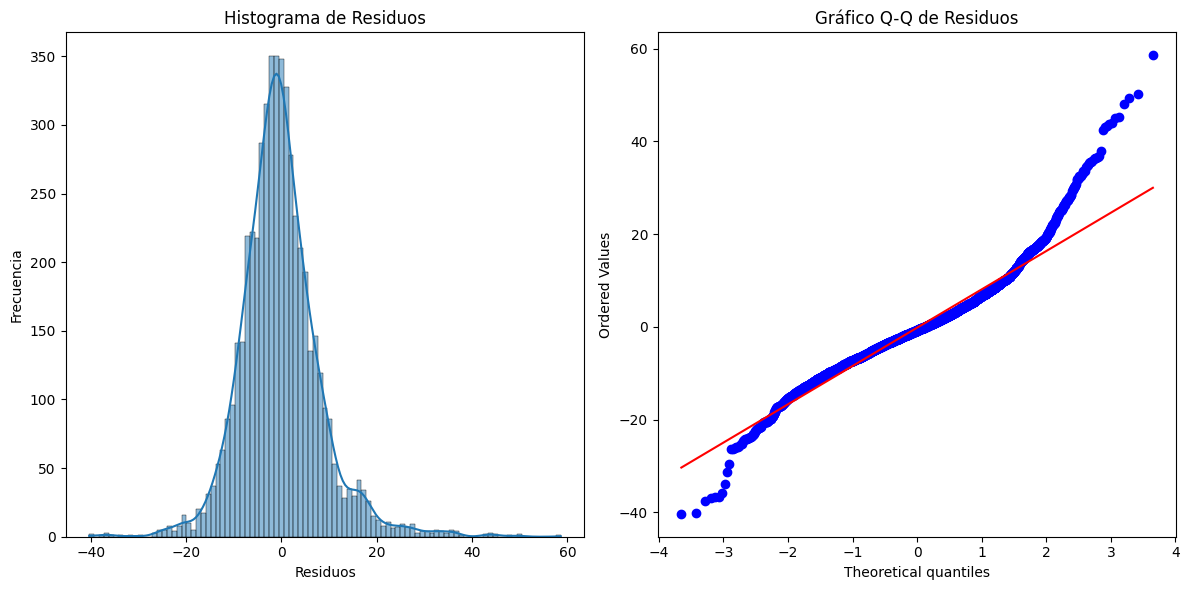

In [ ]:
# Calcular los residuos
residuals3 = y_test3 - y_test_pred3

# Visualizar los residuos
plt.figure(figsize=(12, 6))

# Histograma de residuos
plt.subplot(1, 2, 1)
sns.histplot(residuals3, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

# Gráfico Q-Q
plt.subplot(1, 2, 2)
stats.probplot(residuals3, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')

plt.tight_layout()
plt.show()

## 7. Busqueda de hiperparámetros óptimos con GRID SEARCH para target log_price

In [ ]:

# Se importa librería
from sklearn.model_selection import GridSearchCV

# Se define el rango de hiperparámetros a evaluar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Se crea el modelo
model1 = xgb.XGBRegressor(objective='reg:squarederror')

# Se crea el gridSearch
grid_search1 = GridSearchCV(estimator=model1, param_grid=param_grid,
                          cv=5, scoring='r2', verbose=2, n_jobs=-1)

# Ejecutando el gridSearch
grid_search1.fit(X_train1, y_train1)

# Se imprimen los hiperparámetros encontrados
print("Best parameters found: ", grid_search1.best_params_)





Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters found:  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


Correr el modelo con los hiperparámetros encontrados

In [ ]:
# Crear XGBoost modelo con los hiperparámetros óptimos
model1p = xgb.XGBRegressor(objective='reg:squarederror',
                          learning_rate=grid_search1.best_params_['learning_rate'],
                          max_depth=grid_search1.best_params_['max_depth'],
                          n_estimators=grid_search1.best_params_['n_estimators'],
                          colsample_bytree =grid_search1.best_params_['colsample_bytree'],
                          subsample = grid_search1.best_params_['subsample'])

# Entrenar el modelo
model1p.fit(X_train1, y_train1)

# Hacer predicciones con la data de entrenamiento
y_train_pred1p = model1p.predict(X_train1)

# Predicciones con la data de prueba
y_test_pred1p = model1p.predict(X_test1)

#Calcular R² para el conjunto de entrenamiento
r2_train1p = r2_score(y_train1, y_train_pred1p)
print(f'R² en el conjunto de entrenamiento: {r2_train1p}')

#Calcular R² para el conjunto de entrenamiento transformado log
r2_trainl1p = r2_score(np.exp(y_train1), np.exp(y_train_pred1p))
print(f'R² en el conjunto de entrenamiento trasnformado log: {r2_trainl1p}')

# Calcular R² para el conjunto de prueba
r2_test1p = r2_score(y_test1, y_test_pred1p)
print(f'R² en el conjunto de prueba: {r2_test1p}')

# Calcular R² para el conjunto de prueba transformado log
r2_testl1p = r2_score(np.exp(y_test1), np.exp(y_test_pred1p))
print(f'R² en el conjunto de prueba trasnformado log: {r2_testl1p}')


# Calcular R² ajustado para el conjunto de entrenamiento
n = len(y_train1)
k = X_train1.shape[1]
r2_ajustado_train1p = 1 - (1 - r2_trainl1p) * (n - 1) / (n - k - 1)
print(f'R² ajustado en el conjunto de entrenamiento: {r2_ajustado_train1p}')

# Calcular  R² ajustado para el conjunto de prueba
n = len(y_test1)
k = X_test1.shape[1]
r2_ajustado_test1p = 1 - (1 - r2_testl1p) * (n - 1) / (n - k - 1)
print(f'R² ajustado en el conjunto de prueba: {r2_ajustado_test1p}')

# Calcular MAE para el conjunto de entrenamiento
mae_train1p = mean_absolute_error(y_train1, y_train_pred1p)
print(f'MAE en el conjunto de entrenamiento: {mae_train1p}')

# Calcular MAE para el conjunto de prueba
mae_test1p = mean_absolute_error(y_test1, y_test_pred1p)
print(f'MAE en el conjunto de prueba: {mae_test1p}')

# Calcular MAPE para el conjunto de entrenamiento
mape_train1p = np.mean(np.abs((y_train1 - y_train_pred1p) / y_train1)) * 100
print(f'MAPE en el conjunto de entrenamiento: {mape_train1p}')

# Calcular MAPE para el conjunto de prueba
mape_test1p = np.mean(np.abs((y_test1 - y_test_pred1p) / y_test1)) * 100
print(f'MAPE en el conjunto de prueba: {mape_test1p}')

# Calcular MAPE conjunto entrenamiento transformado log
mape_trainl1p = np.mean(np.abs((np.exp(y_train1) - np.exp(y_train_pred1p)) / np.exp(y_train1))) * 100
print(f'MAPE transformado log en el conjunto de entrenamiento: {mape_trainl1p}')

# Calcular MAPE conjunto prueba transformado log
mape_testl1p = np.mean(np.abs((np.exp(y_test1) - np.exp(y_test_pred1p)) / np.exp(y_test1))) * 100
print(f'MAPE transformado log en el conjunto de prueba: {mape_testl1p}')




R² en el conjunto de entrenamiento: 0.8909073645540512
R² en el conjunto de entrenamiento trasnformado log: 0.8972355336992309
R² en el conjunto de prueba: 0.7096797008299687
R² en el conjunto de prueba trasnformado log: 0.7282072433869233
R² ajustado en el conjunto de entrenamiento: 0.8966512652910882
R² ajustado en el conjunto de prueba: 0.7245736503840747
MAE en el conjunto de entrenamiento: 0.11854126230464283
MAE en el conjunto de prueba: 0.19809742945698955
MAPE en el conjunto de entrenamiento: 1.54176975662785
MAPE en el conjunto de prueba: 2.5770646715759833
MAPE transformado log en el conjunto de entrenamiento: 11.969037432212467
MAPE transformado log en el conjunto de prueba: 20.45991841462541


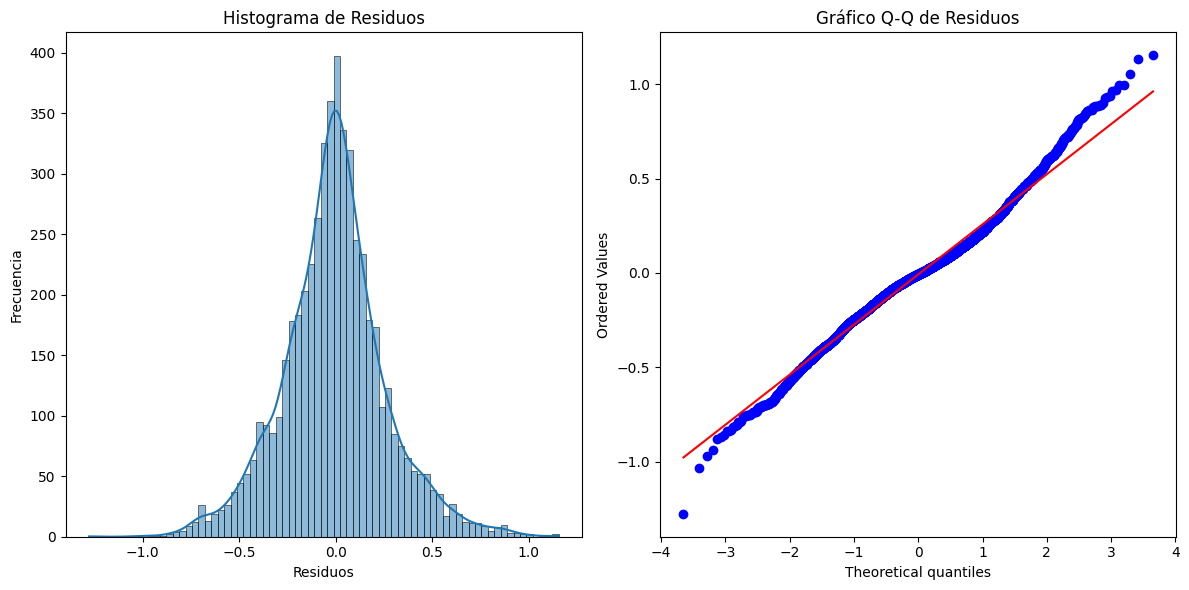

In [ ]:

# Se evaluan los residuos del modelo corridos para comprobar la distribución de los mismos
# Calcular los residuos
residuals1p = y_test1 - y_test_pred1p

# Visualizar los residuos
plt.figure(figsize=(12, 6))

# Histograma de residuos
plt.subplot(1, 2, 1)
sns.histplot(residuals1p, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

# Gráfico Q-Q
plt.subplot(1, 2, 2)
stats.probplot(residuals1p, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')

plt.tight_layout()
plt.show()


Se calculan dos registros con pocad diferencia y que el modelo no predice bien el valor de la renta

In [ ]:

#
equal_prediction_index = np.where(np.isclose(y_test1, y_test_pred1p))[0]

if len(equal_prediction_index) > 0:
  equal_prediction_row = dfred.iloc[X_test1.iloc[equal_prediction_index[0]].name]  # Obtener la fila del DataFrame original
  print("Registro donde el valor estimado es igual al valor real:")
  print(equal_prediction_row)
else:
  print("No se encontró ningún registro donde el valor estimado sea igual al valor real.")



lower_prediction_index = np.where(y_test_pred1p < y_test1)[0]

if len(lower_prediction_index) > 0:
  lower_prediction_row = dfred.iloc[X_test1.iloc[lower_prediction_index[0]].name]  # Obtener la fila del DataFrame original
  print("\nRegistro donde el valor estimado es inferior al valor real:")
  print(lower_prediction_row)
else:
  print("\nNo se encontró ningún registro donde el valor estimado sea inferior al valor real.")


Registro donde el valor estimado es igual al valor real:
floor            3.0
price         4900.0
operation       rent
size           150.0
exterior           1
               ...  
cluster_20         0
cluster_21         0
cluster_22         0
cluster_23         0
cluster_24         0
Name: 10861, Length: 77, dtype: object

Registro donde el valor estimado es inferior al valor real:
floor            0.0
price         4290.0
operation       sale
size            55.0
exterior           1
               ...  
cluster_20         0
cluster_21         0
cluster_22         0
cluster_23         0
cluster_24         0
Name: 17553, Length: 77, dtype: object


Se extrae registro y se calcula el valor predicho considerando las características del inmueble para el caso con poca diferencia

In [ ]:

# Obtener la fila correspondiente al registro 10861
row_10861 = dfred.iloc[10861]

# Crear un DataFrame con solo la fila del registro 10861
df_row_10861 = pd.DataFrame([row_10861])

# Eliminar las columnas que se eliminaron durante el entrenamiento del modelo
df_row_10861 = df_row_10861.drop(columns_to_drop, axis=1)

# Aplicar One-Hot Encoding a la fila
df_row_10861 = pd.get_dummies(df_row_10861)

# Asegurar que las columnas del DataFrame de la fila coincidan con las del modelo
for col in X_train1.columns:
    if col not in df_row_10861.columns:
        df_row_10861[col] = 0

# Hacer una predicción con el modelo para la fila del registro 10861
predicted_price_10861 = np.exp(model1p.predict(df_row_10861))

# Imprimir el precio predicho para el registro 10861
print("El precio predicho para el registro 10861 es:", predicted_price_10861[0])


El precio predicho para el registro 10861 es: 4900.12


Se imprime el valor de renta real del registro con poca diferencia frente al valor predicho

In [ ]:

print("El valor de la columna price para el registro 10861 es:", dfred.loc[10861, 'price'])

El valor de la columna price para el registro 10861 es: 4900.0


Se extrae registro y se calcula el valor predicho considerando las características del inmueble para el caso que difiere en forma considerable

In [ ]:
# Obtener la fila correspondiente al registro 17553
row_17553 = dfred.iloc[17553]

# Crear un DataFrame con solo la fila del registro 17553
df_row_17553 = pd.DataFrame([row_17553])

# Eliminar las columnas que se eliminaron durante el entrenamiento del modelo
df_row_17553 = df_row_17553.drop(columns_to_drop, axis=1)

# Aplicar One-Hot Encoding a la fila
df_row_17553 = pd.get_dummies(df_row_17553)

# Asegurar que las columnas del DataFrame de la fila coincidan con las del modelo
for col in X_train1.columns:
    if col not in df_row_17553.columns:
        df_row_17553[col] = 0

# Hacer una predicción con el modelo para la fila del registro 17553
predicted_price_17553 = np.exp(model1p.predict(df_row_17553))

# Imprimir el precio predicho para el registro 17553
print("El precio predicho para el registro 17553 es:", predicted_price_17553[0])


El precio predicho para el registro 17553 es: 2353.7686


Se imprime el valor de renta correspondiente al registro con variación importante

In [ ]:
print("El valor de la columna price para el registro 17553 es:", dfred.loc[17553, 'price'])

El valor de la columna price para el registro 17553 es: 4290.0


INSTALACION DE LIBRERIA SHAP

In [ ]:
!pip install shap
import shap # make sure the shap module is imported

shap.initjs()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 13.4 MB/s eta 0:00:00


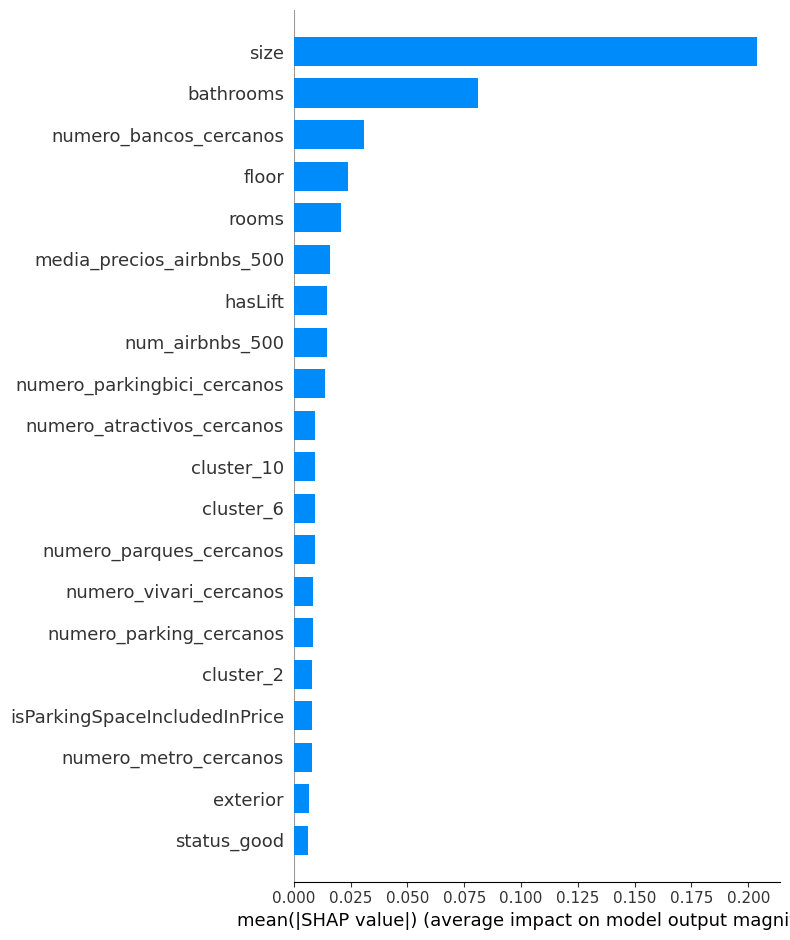

In [ ]:
explainer = shap.TreeExplainer(model1p)
shap_values = explainer.shap_values(X_train1)
shap.summary_plot(shap_values, X_train1, plot_type="bar")

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train1.iloc[0,:])

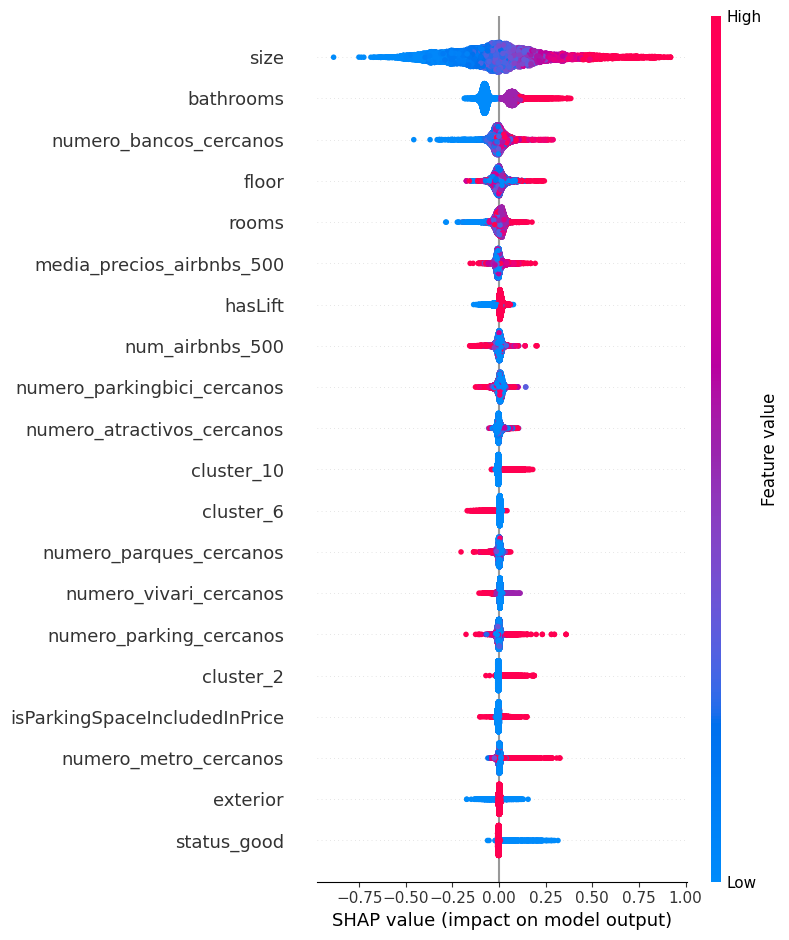

In [ ]:
shap.summary_plot(shap_values, X_train1)